# E-Commerce Customer Intelligence: Cleaning, SQL and EDA

**Goal:** Start from the company database, clean the raw data, answer business questions with SQL, and understand the data with charts.

**Database:** `ecommerce_hackathon.db` (SQLite) with 4 related tables:

| Table | Rows | What it contains |
|---|---|---|
| customers | 8,000 | customer profile and membership |
| products | 1,000 | product, category, brand, price |
| orders | 65,000 | purchases, quantity, discount, delivery, returns |
| reviews | 26,000 | ratings and written reviews |

**Relations:** `customers.customer_id` and `products.product_id` connect to both `orders` and `reviews`.

**Tasks in this notebook:** A (Inspection and Cleaning), B (SQL Business Analysis), C (EDA).

## Step 1: Import Libraries and Connect to the Database

- `sqlite3` connects Python to the SQLite database.
- `pandas` and `numpy` handle tables and numbers.
- `matplotlib` and `seaborn` make charts.
- `warnings` hides unnecessary warning messages.

`run_sql(q)` is a small helper function: we give it a SQL query as text and it returns the result as a pandas table. Using SQL to read the data follows the hackathon rule (do not convert the database to CSV files first).

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

# Connect to the database (the file is in the same folder)
conn = sqlite3.connect("ecommerce_hackathon.db")

# Small helper: write SQL, get a pandas table back
def run_sql(q):
    return pd.read_sql_query(q, conn)

**Quick check:** the query below reads `sqlite_master` (the database's own list of objects) to confirm that the connection works and that all 4 tables exist.

In [2]:
run_sql("select name from sqlite_master where type = 'table'")

,name
0,customers
1,products
2,orders
3,reviews


## Task A: Database Inspection

### Step 2: Look at all four tables

We use a `for` loop to read every table into a pandas table (DataFrame). For each table we print its **shape** (rows, columns) and its **column names**. All tables are kept in a dictionary called `tables`, then given short names (`customers`, `products`, `orders`, `reviews`) so they are easy to use later.

In [3]:
table_names = ["customers", "products", "orders", "reviews"]
tables = {}                       # empty dictionary: name -> table

for name in table_names:          # repeat for every table
    tables[name] = run_sql("select * from " + name)
    print(name, "->", tables[name].shape)
    print("   columns:", list(tables[name].columns))

customers = tables["customers"]
products = tables["products"]
orders = tables["orders"]
reviews = tables["reviews"]

customers -> (8000, 9)
   columns: ['customer_id', 'customer_name', 'age', 'gender', 'city', 'signup_date', 'membership_type', 'email', 'phone']
products -> (1000, 6)
   columns: ['product_id', 'product_name', 'category', 'brand', 'unit_price', 'stock_quantity']
orders -> (65000, 10)
   columns: ['order_id', 'customer_id', 'product_id', 'order_date', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'returned']
reviews -> (26000, 6)
   columns: ['review_id', 'customer_id', 'product_id', 'review_date', 'rating', 'review_text']


**Observation:** The shapes match the hackathon brief (8,000 / 1,000 / 65,000 / 26,000 rows). `orders` and `reviews` connect to the other two tables through `customer_id` and `product_id`.

### Step 3: Data Quality Checks

We check 5 things: **missing values, duplicates, invalid numbers, inconsistent text and invalid dates.** The brief says the database is "raw", so we do not assume that every record is correct.

#### Check 1: Missing values
For every table we list the columns that contain empty (null) cells. `isnull().sum()` counts the empty cells in each column and `miss[miss > 0]` keeps only the columns that have at least one.

In [4]:
print("MISSING VALUES")
for name in table_names:
    miss = tables[name].isnull().sum()
    print(name, miss[miss > 0].to_dict())

MISSING VALUES
customers {'age': 100}
products {'brand': 20}
orders {'payment_method': 55, 'delivery_days': 40}
reviews {'review_text': 48}


#### Check 2: Duplicates and repeated values
- First we check for completely identical rows (`duplicated()`).
- Then we look at customer emails (is one email shared by several customers?).
- Finally we look at repeated review texts. This check uses only the **real (non-empty) texts**, otherwise empty or missing texts would also be counted as duplicates of each other.

In [5]:
print("DUPLICATES")
for name in table_names:
    print(name, "full-row duplicates:", tables[name].duplicated().sum())

# Only real (non-empty) review texts
valid_texts = reviews["review_text"].dropna()
valid_texts = valid_texts[valid_texts.str.strip() != ""]

print("customers duplicate emails:", customers["email"].duplicated().sum())
print("reviews valid texts       :", len(valid_texts))
print("reviews duplicate texts   :", valid_texts.duplicated().sum())
print("reviews unique texts      :", valid_texts.nunique())

DUPLICATES
customers full-row duplicates: 0
products full-row duplicates: 0
orders full-row duplicates: 0
reviews full-row duplicates: 0
customers duplicate emails: 35
reviews valid texts       : 25910
reviews duplicate texts   : 21425
reviews unique texts      : 4485


**Reading this result:** there are no duplicate records (every row has its own ID). The repeated review texts are *not* duplicate records: they are different reviews (different customer, product and review_id) that happen to use the same sentence. We keep them, but we will remember this later because it matters for the sentiment model.

#### Check 3: Invalid numbers
Some values are impossible:
- quantity 0 or negative (nothing was sold)
- price 0 or negative
- a rating outside 1 to 5 (the rating scale is 1 to 5)

`~` means "not", so `(~rating.between(1, 5))` counts the ratings that are **not** between 1 and 5.

In [6]:
print("orders quantity <= 0      :", (orders["quantity"] <= 0).sum())
print("orders unit_price <= 0    :", (orders["unit_price"] <= 0).sum())
print("reviews rating outside 1-5:", (~reviews["rating"].between(1, 5)).sum())
print("customers age min / max   :", customers["age"].min(), customers["age"].max())

orders quantity <= 0      : 45
orders unit_price <= 0    : 35
reviews rating outside 1-5: 25
customers age min / max   : 18.0 65.0


#### Check 4: Inconsistent text
The same thing can be written in different ways ("karachi", "KARACHI", " Karachi "), which the computer treats as different values. We check how many different names exist in `city` and `category`, and how many remain after removing extra spaces (`strip`) and making only the first letter capital (`title`).

In [7]:
print("city unique (raw)          :", customers["city"].nunique())
print("city after strip+title     :", customers["city"].str.strip().str.title().nunique())
print("category unique (raw)      :", products["category"].nunique())
print("category after strip+title :", products["category"].str.strip().str.title().nunique())

city unique (raw)          : 44
city after strip+title     : 13
category unique (raw)      : 19
category after strip+title : 8


#### Check 5: Invalid dates
`pd.to_datetime(..., errors="coerce")` converts text to dates. A date that cannot be understood (like `2025-00-14`, `31-02-2025` or `unknown`) becomes empty (`NaT`) instead of crashing. Then we count the empty dates.

In [8]:
order_dates = pd.to_datetime(orders["order_date"], errors="coerce")
review_dates = pd.to_datetime(reviews["review_date"], errors="coerce")

print("orders bad dates :", order_dates.isna().sum())
print("examples         :", orders.loc[order_dates.isna(), "order_date"].unique().tolist())
print("reviews bad dates:", review_dates.isna().sum())

orders bad dates : 30
examples         : ['2025-00-14', '2026/13/01', 'unknown', '31-02-2025']
reviews bad dates: 16


### Data Quality Summary

| Problem | Where | Details |
|---|---|---|
| Missing values | customers, products, orders, reviews | age (100), brand (20), payment_method (55), delivery_days (40), review_text (48) |
| Inconsistent text | city, category | extra spaces and different capital/small letters (city 44 -> 13, category 19 -> 8 after cleaning) |
| Invalid numbers | orders, reviews | quantity 0 (45), negative price (35), rating 0 or 6 (25) |
| Invalid dates | orders, reviews | 30 order dates and 16 review dates are invalid |
| Duplicates | customers, reviews | no full-row duplicates; 35 emails are shared by different customers; review sentences are heavily repeated (only 4,485 unique texts) |

In the next step we fix each problem and write down the reason.

---
## Task A: Cleaning

### Step 4: Cleaning decisions

The brief says: **do not delete records without a reason.** So for every problem we write the fix and the reason.

| Problem | Fix | Reason |
|---|---|---|
| City / category text inconsistent | `strip()` + `title()` | "karachi", "KARACHI" and " Karachi " are the same city |
| `age` missing (100) | fill with the median | the median is not affected by extreme values |
| `brand` missing (20) | fill with "Unknown" | we keep the product; brand is not important for the analysis |
| Order date invalid (30) | drop those rows | we cannot place the order in time (dates are needed for the monthly trend and the churn windows) |
| `quantity` = 0 (45) | drop those rows | nothing was sold, so it is not a real purchase |
| `unit_price` negative (35) | use the product's catalog price | the order price is within about +-17% of the catalog price, so the catalog price is a safe repair (we do not delete these orders) |
| `payment_method` missing (55) | fill with "Unknown" | we keep the order and its revenue |
| `delivery_days` missing (40) | fill with the median | very few rows |
| `review_text` empty or missing (90) | drop (reviews only) | without text there is nothing to learn from |
| `rating` 0 or 6 (25) | drop (reviews only) | the rating scale is 1 to 5, so no sentiment label can be made |
| `review_date` invalid (16) | **keep** the review, set the date to empty (`NaT`) | the sentiment model needs only the text and the rating, so we do not delete useful reviews because of a bad date |
| Duplicate emails (35) | keep | different names and phones, so they are different customers |

First we clean `customers` and `products`.

In [9]:
# .copy() makes a photocopy of the table so the raw data stays safe
customers_clean = customers.copy()
customers_clean["city"] = customers_clean["city"].str.strip().str.title()
customers_clean["age"] = customers_clean["age"].fillna(customers_clean["age"].median())
customers_clean["signup_date"] = pd.to_datetime(customers_clean["signup_date"])

products_clean = products.copy()
products_clean["category"] = products_clean["category"].str.strip().str.title()
products_clean["brand"] = products_clean["brand"].fillna("Unknown")

print("cities    :", customers_clean["city"].nunique())
print("categories:", products_clean["category"].nunique())

cities    : 13
categories: 8


Now we clean **orders**. There are 5 jobs: drop rows with an invalid date, drop rows with quantity 0, repair negative prices, fill the other missing values, and create the `net_revenue` column.

- `errors="coerce"` turns an invalid date into empty (`NaT`), then `dropna` removes those rows.
- For negative prices we first `merge` the catalog price from `products_clean`, then copy it only into the wrong rows.
- **`net_revenue = quantity x unit_price x (1 - discount)`**, the money after the discount.

In [10]:
orders_clean = orders.copy()

# 1) Fix the date column and drop rows with an invalid date
orders_clean["order_date"] = pd.to_datetime(orders_clean["order_date"], errors="coerce")
before = len(orders_clean)
orders_clean = orders_clean.dropna(subset=["order_date"])
print("rows dropped (bad date):", before - len(orders_clean))

# 2) Drop rows with quantity 0
before = len(orders_clean)
orders_clean = orders_clean[orders_clean["quantity"] > 0]
print("rows dropped (quantity 0):", before - len(orders_clean))

# 3) Replace a negative price with the catalog price
orders_clean = orders_clean.merge(
    products_clean[["product_id", "unit_price"]],
    on="product_id", how="left", suffixes=("", "_catalog"))
bad_price = orders_clean["unit_price"] <= 0
print("negative prices fixed:", bad_price.sum())
orders_clean.loc[bad_price, "unit_price"] = orders_clean.loc[bad_price, "unit_price_catalog"]
orders_clean = orders_clean.drop(columns="unit_price_catalog")

# 4) Other missing values
orders_clean["payment_method"] = orders_clean["payment_method"].fillna("Unknown")
orders_clean["delivery_days"] = orders_clean["delivery_days"].fillna(orders_clean["delivery_days"].median())

# 5) Net revenue column (money after the discount)
orders_clean["net_revenue"] = orders_clean["quantity"] * orders_clean["unit_price"] * (1 - orders_clean["discount"])

rows dropped (bad date): 30
rows dropped (quantity 0): 45
negative prices fixed: 35


Now we clean **reviews**. We remove empty texts and ratings outside 1 to 5. A review with an invalid date is **kept**: we only turn its date into `NaT`. This affects only the reviews table.

In [11]:
reviews_clean = reviews.copy()
before = len(reviews_clean)

reviews_clean["review_text"] = reviews_clean["review_text"].fillna("").str.strip()
reviews_clean = reviews_clean[reviews_clean["review_text"] != ""]
reviews_clean = reviews_clean[reviews_clean["rating"].between(1, 5)]

# Invalid review dates: keep the review, just make the date empty (NaT)
reviews_clean["review_date"] = pd.to_datetime(reviews_clean["review_date"], errors="coerce")

print("reviews rows dropped:", before - len(reviews_clean))
print("reviews with an invalid date (kept, date = NaT):", reviews_clean["review_date"].isna().sum())

reviews rows dropped: 115
reviews with an invalid date (kept, date = NaT): 16


### Check after cleaning

We confirm that the cleaning worked: no missing values are left, price and quantity are valid, and the city and category names are clean.

In [12]:
print("customers", customers_clean.shape, "| missing:", customers_clean.isnull().sum().sum())
print("products ", products_clean.shape, "| missing:", products_clean.isnull().sum().sum())
print("orders   ", orders_clean.shape, "| missing:", orders_clean.isnull().sum().sum())
print("reviews  ", reviews_clean.shape)
print()
print("orders min price:", orders_clean["unit_price"].min(), "| min quantity:", orders_clean["quantity"].min())
print("orders date range:", orders_clean["order_date"].min().date(), "to", orders_clean["order_date"].max().date())
print("cities    :", sorted(customers_clean["city"].unique()))
print("categories:", sorted(products_clean["category"].unique()))

customers (8000, 9) | missing: 0
products  (1000, 6) | missing: 0
orders    (64925, 11) | missing: 0
reviews   (25885, 6)

orders min price: 67.62 | min quantity: 1
orders date range: 2022-03-26 to 2026-08-31
cities    : ['Bahawalpur', 'Faisalabad', 'Gujranwala', 'Hyderabad', 'Islamabad', 'Karachi', 'Lahore', 'Multan', 'Peshawar', 'Quetta', 'Rawalpindi', 'Sargodha', 'Sialkot']
categories: ['Baby & Kids', 'Beauty', 'Books & Stationery', 'Electronics', 'Fashion', 'Groceries', 'Home & Kitchen', 'Sports & Fitness']


**Observation:**
- Only **75 order rows** were removed (30 invalid dates + 45 with quantity 0), which is just **0.12%** of 65,000. From reviews we removed 115 rows (90 empty texts + 25 invalid ratings); the 16 reviews with an invalid date were kept.
- All other problems were **repaired**, not deleted (negative prices, missing values, inconsistent text).
- There are now **13** cities and **8** categories, no table has missing values, and the order dates run from 2022 to 2026-08-31 (data exists for the churn target window).

`customers_clean`, `products_clean`, `orders_clean` and `reviews_clean` are ready. The next tasks (SQL analysis and EDA) use these clean tables.

---
## Task B: SQL Business Analysis

Now we answer **5 business questions** with **SQL** (the brief requires the business queries to be written in SQL).

### Two important decisions

**1) Definition of net revenue**

> **net revenue = quantity x price x (1 - discount)**, counting only orders that were **not returned**.

Reason: when an order is returned the company gives the money back, so it is not real income.

**2) The cleaning must also happen inside SQL**

In Task A we cleaned the data with pandas, but SQL runs directly on the **raw database**. So we repeat the same cleaning in SQL, to make sure both give the same numbers:
- `date(order_date) IS NOT NULL`: skip rows with an invalid date
- `quantity > 0`: skip rows with quantity 0
- `CASE WHEN unit_price > 0 ...`: use the product's catalog price instead of a negative price
- `returned = 0`: skip returned orders

All these conditions are written once, inside a **CTE** (`WITH sales AS (...)`). A CTE is a **temporary table** that exists only while the query runs. In every query we then read from `sales` like from a normal table.

**Why `FROM sales` and not `FROM orders`?** `sales` is the *clean* version of `orders`. Using `orders` directly would count about 4,350 returned orders (about 70 million Rs) and the invalid rows, and it would give 935.98 million instead of 865.63 million. The raw `orders` table also has no column called `price` (it is called `unit_price`, and a few values are negative).

In [13]:
sales_cte = '''
WITH sales AS (
    SELECT o.order_id, o.customer_id, o.product_id,
           date(o.order_date) AS order_date,
           o.quantity,
           CASE WHEN o.unit_price > 0 THEN o.unit_price ELSE p.unit_price END AS price,
           o.discount
    FROM orders o
    JOIN products p ON o.product_id = p.product_id
    WHERE date(o.order_date) IS NOT NULL
      AND o.quantity > 0
      AND o.returned = 0
)
'''
print(sales_cte)


WITH sales AS (
    SELECT o.order_id, o.customer_id, o.product_id,
           date(o.order_date) AS order_date,
           o.quantity,
           CASE WHEN o.unit_price > 0 THEN o.unit_price ELSE p.unit_price END AS price,
           o.discount
    FROM orders o
    JOIN products p ON o.product_id = p.product_id
    WHERE date(o.order_date) IS NOT NULL
      AND o.quantity > 0
      AND o.returned = 0
)



### Query 1: Total Net Revenue

`SUM(quantity * price * (1 - discount))` calculates the money of every order after the discount and adds them up. `ROUND(..., 2)` rounds to two decimals.

In [14]:
q1 = sales_cte + '''
SELECT ROUND(SUM(quantity * price * (1 - discount)), 2) AS total_net_revenue,
       COUNT(*) AS total_orders
FROM sales;
'''
run_sql(q1)

,total_net_revenue,total_orders
0,8.656283e+08,60581


**Check:** we compare the SQL answer with the pandas answer. They should be equal, which proves that the cleaning is the same in SQL and in pandas.

In [15]:
pandas_total = orders_clean.loc[orders_clean["returned"] == 0, "net_revenue"].sum()
sql_total = run_sql(q1)["total_net_revenue"][0]
print("pandas total:", round(pandas_total, 2))
print("SQL total   :", sql_total)
print("Match       :", abs(pandas_total - sql_total) < 1)

pandas total: 865628304.16
SQL total   : 865628304.16
Match       : True


### Query 2: Top 10 Customers by Spending

We join 2 tables: `sales` and `customers` (using `customer_id`). Then:
- `GROUP BY c.customer_id` puts all orders of one customer in one group
- `COUNT(*)` counts the orders of that customer
- `SUM(...)` adds up the money spent
- `ORDER BY ... DESC LIMIT 10` keeps the 10 biggest spenders

For the city name we use `trim` (remove extra spaces), `upper(substr(...,1,1))` (first letter capital) and `lower(substr(...,2))` (rest small), so "karachi" and "KARACHI" count as the same city.

In [16]:
q2 = sales_cte + '''
SELECT c.customer_name,
       upper(substr(trim(c.city), 1, 1)) || lower(substr(trim(c.city), 2)) AS city,
       COUNT(*) AS number_of_orders,
       ROUND(SUM(s.quantity * s.price * (1 - s.discount)), 2) AS total_spending
FROM sales s
JOIN customers c ON s.customer_id = c.customer_id
GROUP BY c.customer_id
ORDER BY total_spending DESC
LIMIT 10;
'''
run_sql(q2)

,customer_name,city,number_of_orders,total_spending
0,Shahzaib Abbasi,Lahore,37,1537800.62
1,Zoya Awan,Lahore,50,1515401.07
2,Ahmed Qureshi,Lahore,27,1452407.09
3,Kiran Farooq,Karachi,57,1353157.41
4,Laiba Khan,Karachi,40,1340945.41
5,Adeel Khan,Karachi,38,1333846.74
6,Fahad Khan,Islamabad,51,1252693.65
7,Bilal Awan,Karachi,45,1248563.98
8,Imran Qureshi,Karachi,44,1247069.53
9,Danish Awan,Faisalabad,43,1240877.18


### Query 3: Category-wise Revenue, Order Count and Quantity

We join `sales` with `products` to get the category. Category names had extra spaces and mixed capital/small letters, so `lower(trim(...))` makes them uniform.

In [17]:
q3 = sales_cte + '''
SELECT lower(trim(p.category)) AS category,
       ROUND(SUM(s.quantity * s.price * (1 - s.discount)), 2) AS net_revenue,
       COUNT(*) AS order_count,
       SUM(s.quantity) AS quantity_sold
FROM sales s
JOIN products p ON s.product_id = p.product_id
GROUP BY lower(trim(p.category))
ORDER BY net_revenue DESC;
'''
run_sql(q3)

,category,net_revenue,order_count,quantity_sold
0,electronics,6.047965e+08,10619,14865
1,home & kitchen,6.720334e+07,7121,10051
2,fashion,5.535869e+07,10865,15233
3,sports & fitness,5.149576e+07,6658,9357
4,beauty,4.430083e+07,11014,15309
5,baby & kids,2.730627e+07,3535,5048
6,groceries,7.848498e+06,5949,8314
7,books & stationery,7.318386e+06,4820,6675


### Query 4: Monthly Net Revenue Trend

`strftime('%Y-%m', order_date)` takes the year and month out of a date (for example `2026-05`). Then we group by month and add up the revenue.

In [18]:
q4 = sales_cte + '''
SELECT strftime('%Y-%m', order_date) AS month,
       ROUND(SUM(quantity * price * (1 - discount)), 2) AS net_revenue
FROM sales
GROUP BY strftime('%Y-%m', order_date)
ORDER BY month;
'''
monthly_sql = run_sql(q4)
monthly_sql.tail(8)

,month,net_revenue
46,2026-01,38832293.50
47,2026-02,40033808.05
48,2026-03,46306987.44
49,2026-04,49574061.52
50,2026-05,54959494.57
51,2026-06,60615999.78
52,2026-07,76613711.59
53,2026-08,67750130.96


### Query 5: Top 5 Products by Net Revenue

In [19]:
q5 = sales_cte + '''
SELECT p.product_name,
       lower(trim(p.category)) AS category,
       ROUND(SUM(s.quantity * s.price * (1 - s.discount)), 2) AS net_revenue
FROM sales s
JOIN products p ON s.product_id = p.product_id
GROUP BY p.product_id
ORDER BY net_revenue DESC
LIMIT 5;
'''
run_sql(q5)

,product_name,category,net_revenue
0,Samsung Headphones Classic,electronics,1.058214e+08
1,Anker Headphones Classic,electronics,6.601398e+07
2,Dawlance LED TV Premium,electronics,1.903070e+07
3,Infinix LED TV 2026,electronics,1.565400e+07
4,Dawlance Router Eco,electronics,1.417660e+07


### Save all 5 queries into `queries.sql`

The brief asks for a separate SQL file. The code below writes the 5 queries above into the file `queries.sql`. (`with open(...) as f` opens the file and closes it automatically when the work is done.)

In [20]:
all_queries = [
    ("Query 1: Total net revenue", q1),
    ("Query 2: Top 10 customers by spending", q2),
    ("Query 3: Category-wise revenue, order count and quantity sold", q3),
    ("Query 4: Monthly net revenue trend", q4),
    ("Query 5: Top 5 products by net revenue", q5),
]

with open("queries.sql", "w") as f:
    f.write("-- E-Commerce Hackathon: 5 business queries (SQLite)\n")
    f.write("-- Net revenue = quantity * price * (1 - discount), valid and non-returned orders only\n\n")
    for title, query in all_queries:
        f.write("-- " + title + "\n")
        f.write(query.strip() + "\n\n")

print("queries.sql saved with", len(all_queries), "queries")

queries.sql saved with 5 queries


---
## Task C: Exploratory Data Analysis (EDA)

Now we make **4 charts** from the cleaned data (the `*_clean` tables from Task A).

First we put the tables together (`merge`), so one table has the order, the city and the category. For revenue we keep the same rule: only orders that were **not returned**.

In [21]:
eda = (orders_clean
       .merge(customers_clean[["customer_id", "city"]], on="customer_id", how="left")
       .merge(products_clean[["product_id", "category"]], on="product_id", how="left"))

eda["month"] = eda["order_date"].dt.to_period("M").astype(str)

sales_eda = eda[eda["returned"] == 0]      # for revenue: leave out returned orders

print("eda table:", eda.shape)
print("sales (non-returned):", sales_eda.shape)
eda.head(3)

eda table: (64925, 14)
sales (non-returned): (60581, 14)


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,payment_method,delivery_days,returned,net_revenue,city,category,month
0,1,2367,389,2026-04-30,1,398.27,0.108,Cash on Delivery,1.0,0,355.25684,Lahore,Home & Kitchen,2026-04
1,2,2038,927,2026-02-09,2,44488.20,0.084,Debit/Credit Card,1.0,0,81502.38240,Lahore,Electronics,2026-02
2,3,6285,909,2026-03-30,1,4719.91,0.125,Cash on Delivery,1.0,0,4129.92125,Faisalabad,Sports & Fitness,2026-03


### Chart 1: Monthly Revenue Trend

`groupby("month")` groups the orders by month and `sum()` adds up the revenue. The amounts are big, so we show them in **millions** (`/ 1_000_000`).

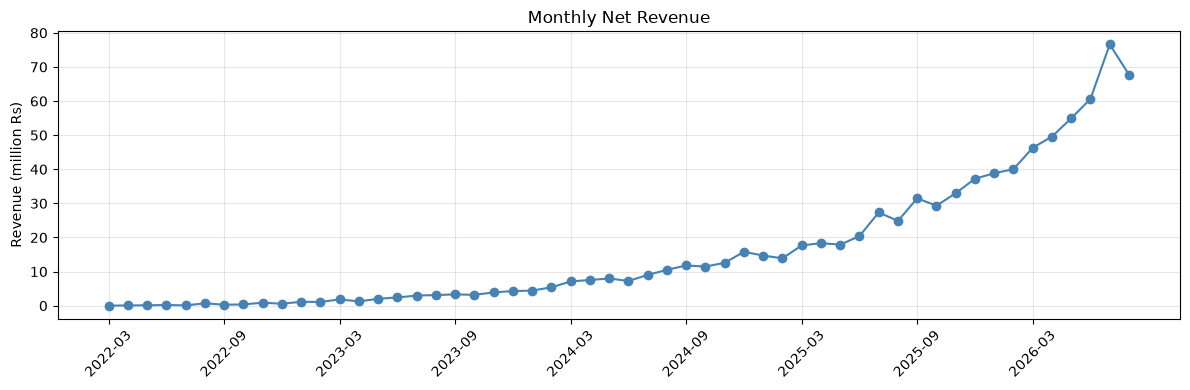

In [22]:
monthly = sales_eda.groupby("month")["net_revenue"].sum() / 1_000_000

plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly.values, marker="o", color="steelblue")
plt.title("Monthly Net Revenue")
plt.ylabel("Revenue (million Rs)")
plt.xticks(range(0, len(monthly), 6), monthly.index[::6], rotation=45)   # show every 6th month
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** Revenue was very small in 2022 (only about 8 thousand Rs in March 2022 and about 3.3 million Rs in the whole of 2022) and then grew every year: about 30.6 million in 2023, 110.9 million in 2024, 286.1 million in 2025, and already 434.7 million in the first 8 months of 2026. July 2026 was the highest month (about 76 million Rs) and August 2026 was a little lower (about 68 million Rs).

### Chart 2: Category-wise Revenue

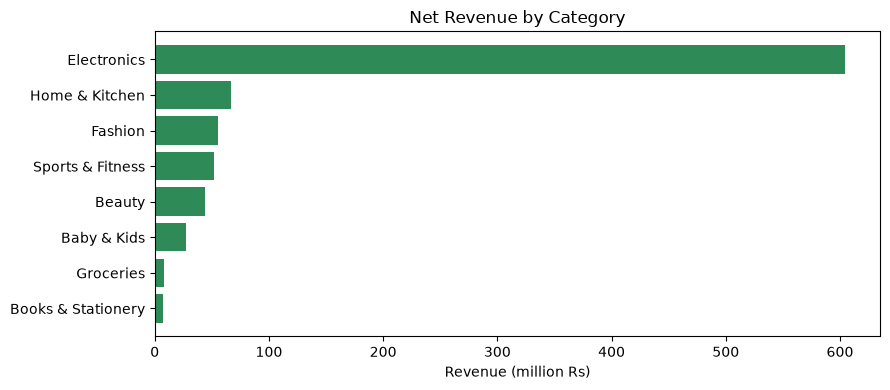

category
Electronics           69.9
Home & Kitchen         7.8
Fashion                6.4
Sports & Fitness       5.9
Beauty                 5.1
Baby & Kids            3.2
Groceries              0.9
Books & Stationery     0.8
Name: net_revenue, dtype: float64


In [23]:
category_rev = sales_eda.groupby("category")["net_revenue"].sum().sort_values() / 1_000_000

plt.figure(figsize=(9, 4))
plt.barh(category_rev.index, category_rev.values, color="seagreen")
plt.title("Net Revenue by Category")
plt.xlabel("Revenue (million Rs)")
plt.tight_layout()
plt.show()

print((category_rev / category_rev.sum() * 100).round(1).sort_values(ascending=False))

**Observation:** **Electronics** alone gives about **70%** of the revenue. The other 7 categories together give only 30%. Groceries and Books & Stationery are very small (below 1%).

### Chart 3: City-wise Revenue

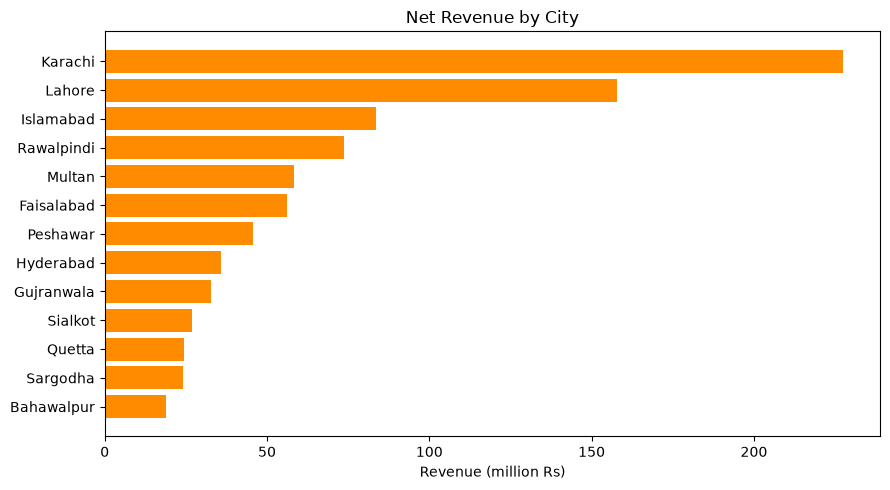

city
Karachi       26.3
Lahore        18.2
Islamabad      9.7
Rawalpindi     8.5
Multan         6.8
Name: net_revenue, dtype: float64


In [24]:
city_rev = sales_eda.groupby("city")["net_revenue"].sum().sort_values() / 1_000_000

plt.figure(figsize=(9, 5))
plt.barh(city_rev.index, city_rev.values, color="darkorange")
plt.title("Net Revenue by City")
plt.xlabel("Revenue (million Rs)")
plt.tight_layout()
plt.show()

print((city_rev / city_rev.sum() * 100).round(1).sort_values(ascending=False).head(5))

**Observation:** **Karachi** (about 26%) and **Lahore** (about 18%) together give roughly 44% of the revenue. The other cities have a much smaller share.

### Chart 4: Return Rate by Product Category

Return rate = the average of the `returned` column (it is 0 or 1, so the average is the share of returned orders). We calculate it on all orders (returned and not returned).

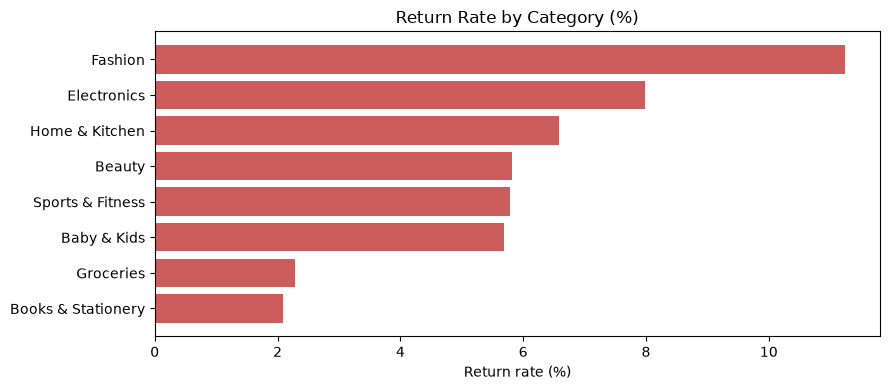

Overall return rate: 6.7 %
category
Fashion               11.2
Electronics            8.0
Home & Kitchen         6.6
Sports & Fitness       5.8
Beauty                 5.8
Baby & Kids            5.7
Groceries              2.3
Books & Stationery     2.1
Name: returned, dtype: float64


In [25]:
return_rate = eda.groupby("category")["returned"].mean().sort_values() * 100

plt.figure(figsize=(9, 4))
plt.barh(return_rate.index, return_rate.values, color="indianred")
plt.title("Return Rate by Category (%)")
plt.xlabel("Return rate (%)")
plt.tight_layout()
plt.show()

print("Overall return rate:", round(eda["returned"].mean() * 100, 1), "%")
print(return_rate.round(1).sort_values(ascending=False))

**Observation:** The overall return rate is about **6.7%**. **Fashion** has the highest (about **11.2%**), followed by Electronics (about 8%). Groceries and Books & Stationery have the lowest (about 2%).

In [26]:
lost = eda.loc[eda["returned"] == 1, "net_revenue"].sum() / eda["net_revenue"].sum() * 100
top2 = sales_eda[sales_eda["product_id"].isin(
    sales_eda.groupby("product_id")["net_revenue"].sum().nlargest(2).index)]["net_revenue"].sum()
print("Revenue lost to returns:", round(lost, 1), "%")
print("Share of the top 2 products:", round(top2 / sales_eda["net_revenue"].sum() * 100, 1), "%")

Revenue lost to returns: 7.6 %
Share of the top 2 products: 19.9 %


### Business Insights

**Insight 1: The company depends too much on Electronics.**
Electronics gives about 70% of the revenue, and just two headphone products (Samsung and Anker) give about 20% by themselves. **Why this is a risk:** if the supply of these few products stops, their price falls or the stock runs out, more than half of the company's income can fall at the same time. **What to do:** grow the other categories (Home & Kitchen, Fashion, Sports) with more marketing so that revenue does not depend on one place.

**Insight 2: Fashion has the most returns.**
The Fashion return rate is about 11%, almost double the overall 6.7%. Size and fit problems are common in fashion. **Why this matters:** every return costs delivery, handling and a refund, and about 7.6% of all revenue goes back through returns. **What to do:** add size charts and better product photos to reduce returns.

**Insight 3: Karachi and Lahore are the biggest markets, and the company is growing fast.**
These two cities together give about 44% of the revenue, and monthly revenue has grown steadily since 2022. **Why this matters:** investing in delivery and marketing in these two cities will pay off the most (for example faster delivery). August 2026 is a little lower than July, which should be watched in the coming months to see whether it is only seasonal or whether the growth is slowing down.